# Lab 2 - Artificial Intelligence (COMP3742)
Student Name: Oliver Wuttke

Student FAN: WUTT0019

File: lab2_exercises.ipynb

Date: 07-08-2026

Description: Python notebook for entirety of lab 2 exercises

In [50]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score
from sklearn.tree import export_graphviz

In [51]:
# Load in dataset
csv_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
col_names = ['Pregnancies', 'Glucose', 'Blood pressure', 'Skin thickness','Insulin', 'Body mass index', 'Diabetes pedigree function', 'Age', 'Outcome']

pid_data = pd.read_csv(csv_url, header=None, names=col_names, engine='python')

# Take a look
print(pid_data.head())

   Pregnancies  Glucose  Blood pressure  Skin thickness  Insulin  \
0            6      148              72              35        0   
1            1       85              66              29        0   
2            8      183              64               0        0   
3            1       89              66              23       94   
4            0      137              40              35      168   

   Body mass index  Diabetes pedigree function  Age  Outcome  
0             33.6                       0.627   50        1  
1             26.6                       0.351   31        0  
2             23.3                       0.672   32        1  
3             28.1                       0.167   21        0  
4             43.1                       2.288   33        1  


In [52]:
# Summary statistics
print(pid_data.describe())

       Pregnancies     Glucose  Blood pressure  Skin thickness     Insulin  \
count   768.000000  768.000000      768.000000      768.000000  768.000000   
mean      3.845052  120.894531       69.105469       20.536458   79.799479   
std       3.369578   31.972618       19.355807       15.952218  115.244002   
min       0.000000    0.000000        0.000000        0.000000    0.000000   
25%       1.000000   99.000000       62.000000        0.000000    0.000000   
50%       3.000000  117.000000       72.000000       23.000000   30.500000   
75%       6.000000  140.250000       80.000000       32.000000  127.250000   
max      17.000000  199.000000      122.000000       99.000000  846.000000   

       Body mass index  Diabetes pedigree function         Age     Outcome  
count       768.000000                  768.000000  768.000000  768.000000  
mean         31.992578                    0.471876   33.240885    0.348958  
std           7.884160                    0.331329   11.760232    

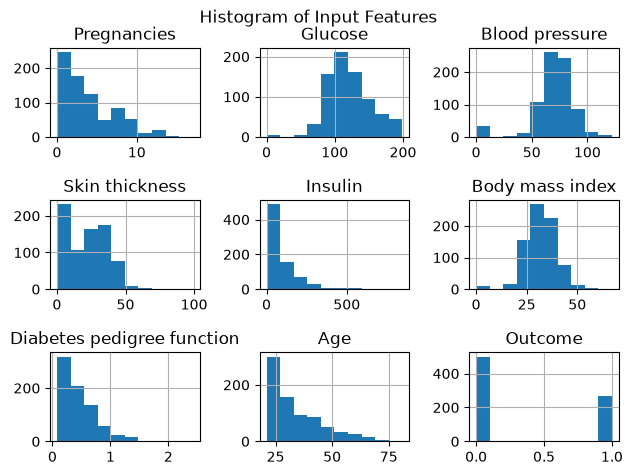

In [53]:
# Plotting the data
pid_data.hist()
plt.suptitle('Histogram of Input Features')
plt.tight_layout()
plt.subplots_adjust(top=0.90)  # room for suptitle
plt.show()

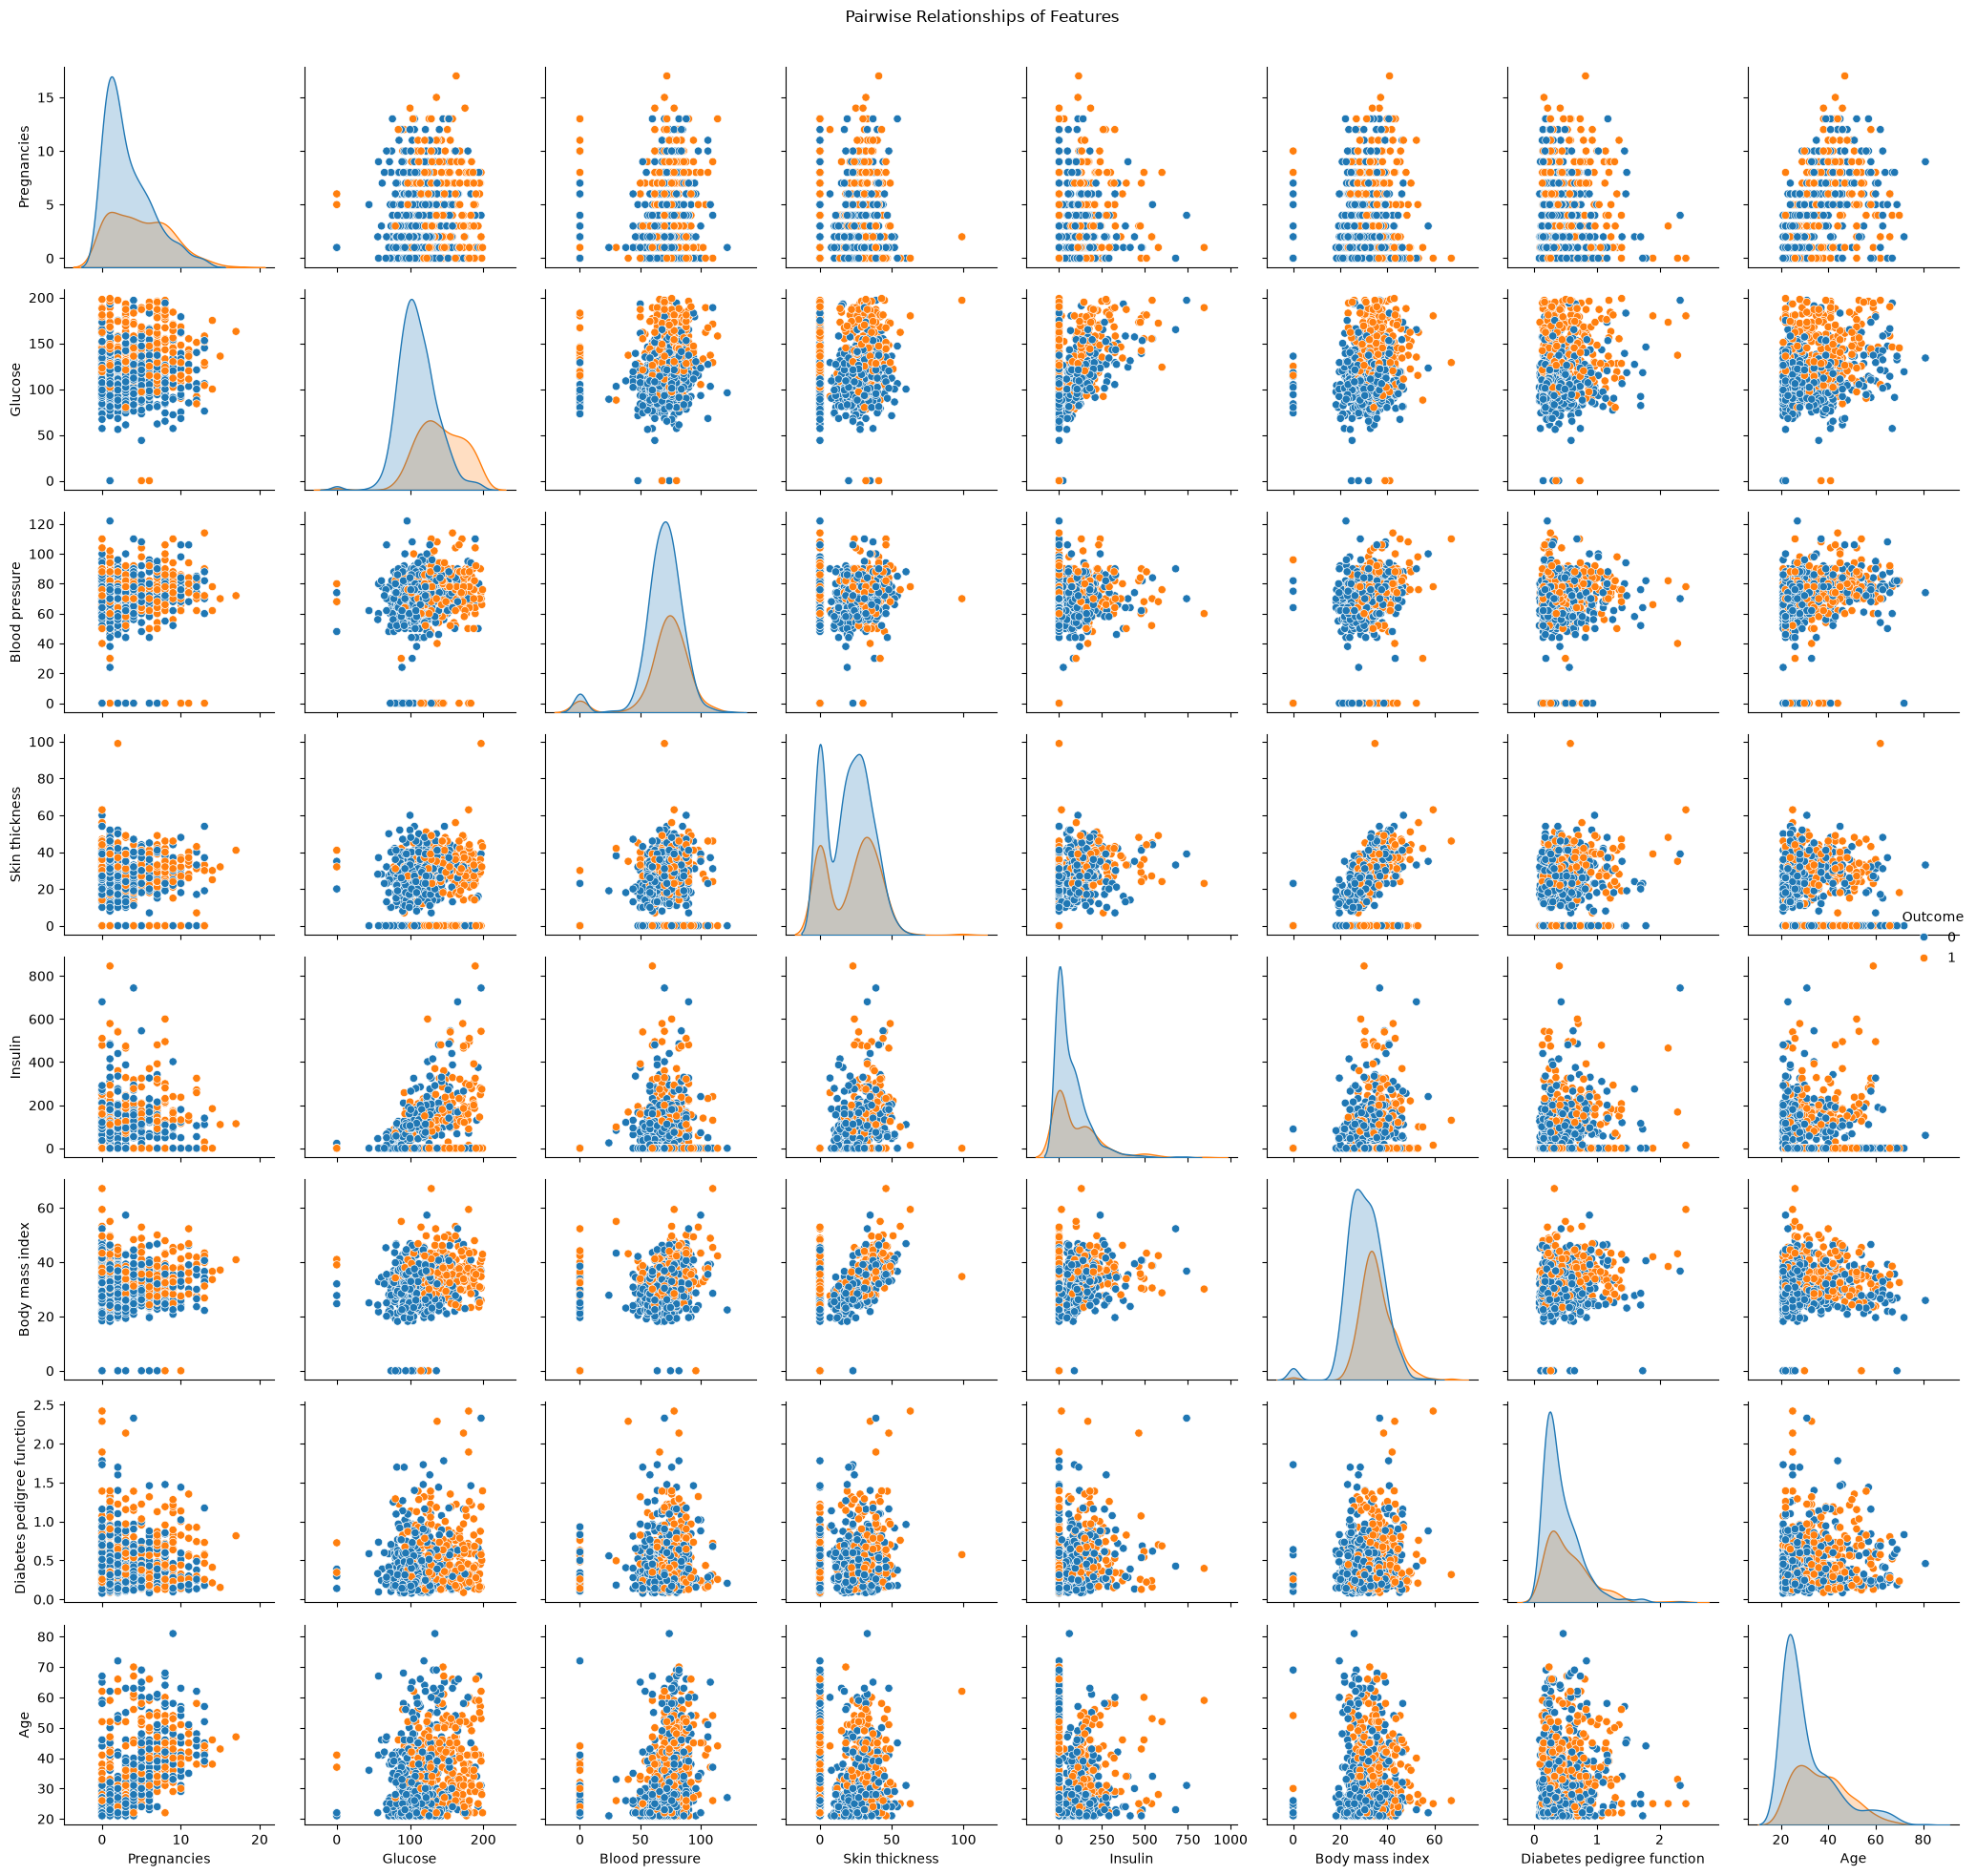

In [54]:
# Plotting pairwise relationships
sns.pairplot(pid_data, hue='Outcome')
plt.suptitle('Pairwise Relationships of Features')
plt.tight_layout()
plt.subplots_adjust(top=0.95)  # room for suptitle
plt.show()

In [55]:
# Train-test split
X = pid_data.drop('Outcome', axis=1)
Y = pid_data['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [56]:
# Fitting and testing prediction accuracy
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

dtc_predictions = dtc.predict(X_test)

accuracy = accuracy_score(y_test, dtc_predictions)
print(f'Accuracy for Predictions: {accuracy:.2f}')

Accuracy for Predictions: 0.77


In [57]:
# Use graphviz to visualize the decision tree model
os.environ['PATH'] += os.pathsep + '/opt/homebrew/Cellar/graphviz'

dot_data = export_graphviz(
    dtc,
    out_file=None,
    feature_names=X.columns,
    class_names=['No Diabetes', 'Diabetes'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph.render("decision_tree")
graph.view()

'decision_tree.pdf'

In [58]:
# Display text representation of the decision tree model
tree_struct = export_text(dtc, feature_names=list(X.columns))
print("Decision Tree Structure:\n", tree_struct)

Decision Tree Structure:
 |--- Glucose <= 127.50
|   |--- Age <= 28.50
|   |   |--- Body mass index <= 30.95
|   |   |   |--- Diabetes pedigree function <= 0.67
|   |   |   |   |--- class: 0
|   |   |   |--- Diabetes pedigree function >  0.67
|   |   |   |   |--- Diabetes pedigree function <= 0.69
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Diabetes pedigree function >  0.69
|   |   |   |   |   |--- class: 0
|   |   |--- Body mass index >  30.95
|   |   |   |--- Blood pressure <= 37.00
|   |   |   |   |--- class: 1
|   |   |   |--- Blood pressure >  37.00
|   |   |   |   |--- Diabetes pedigree function <= 0.50
|   |   |   |   |   |--- Skin thickness <= 8.50
|   |   |   |   |   |   |--- Glucose <= 109.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Glucose >  109.50
|   |   |   |   |   |   |   |--- Glucose <= 123.00
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- Glucose >  123.00
|   |   |   |   |   |   |   |   |--- cl

In [59]:
# Display features of importance
feature_importance = dtc.feature_importances_
feature_importance_summary = sorted(zip(X.columns, feature_importance), key=lambda x: x[1], reverse=True)

print('\n=== Feature Importance ===')
for feature, importance in feature_importance_summary:
    print(f'{feature}: {importance:.4f}')


=== Feature Importance ===
Glucose: 0.3315
Body mass index: 0.1509
Blood pressure: 0.1435
Age: 0.1136
Diabetes pedigree function: 0.0911
Insulin: 0.0592
Skin thickness: 0.0553
Pregnancies: 0.0549


In [60]:
# Grid search cross validation for finding optimal hyperparameters
hyperparam_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 10, 20, 30],
    'max_leaf_nodes': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [4, 10, 20, 50],
    'class_weight': [None, 'balanced'],
    'max_features': [None, 'sqrt', 'log2']
}

dtc_gs = DecisionTreeClassifier()
grid_search = GridSearchCV(estimator=dtc_gs, param_grid=hyperparam_grid, cv=10, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Hyper-parameters: ", grid_search.best_params_)
print("Best Score: ", grid_search.best_score_)

Best Hyper-parameters:  {'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best Score:  0.78011634056055
